# MANA Daily Analytics Generator

This notebook generates daily analytics from MANA minute bar data and stores them in parquet format.

**Analytics generated (all 21-day rolling unless specified):**
- **adv_21_days**: Average Daily Volume (21-day rolling)
- **avg_trade_count_21_days**: Average Daily Trade Count (21-day rolling)
- **avg_spread**: Average spread (21-day rolling)  
- **daily_vwap**: Volume Weighted Average Price (daily)
- **daily_volatility**: Daily volatility (using Parkinson estimator)
- **daily_volatility_lag1**: Daily volatility lag 1
- **daily_volatilityl_5d**: Daily volatility 5-day rolling average
- **avg_depth**: Average bid and offer depth 


In [1]:
import os
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.dataset as ds
import logging
from tqdm import tqdm
import warnings
from typing import Dict, List, Tuple, Optional
from datetime import datetime
warnings.filterwarnings('ignore')

# Configuration
MANA_DATA_PATH = "mana_data/bar_data_parquet"
OUTPUT_PATH = "mana_data/daily_analytics_parquet"
ROLLING_WINDOW = 21  # days
VOLATILITY_WINDOW_5D = 5  # days

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Create output directory
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"✓ Input path: {MANA_DATA_PATH}")
print(f"✓ Output path: {OUTPUT_PATH}")

✓ Input path: mana_data/bar_data_parquet
✓ Output path: mana_data/daily_analytics_parquet


In [26]:
# Ultra-Fast Analytics Functions
from pathlib import Path
from typing import Tuple, Union


def load_symbol_ultra_fast(symbol):
    """
    Load symbol data with maximum speed.
    Assumes each file already contains parsed columns:
    ['time', 'trade_count', 'trade_volume', 'trade_last',
     'trade_high', 'trade_low', 'bid_price', 'bid_size',
     'ask_price', 'ask_size', 'hid_vol', 'buy_vol',
     'sell_vol', 'unsided_vol', 'vwap', 'symbol', 'date']
    @param symbol: symbol to load
    @return: dataframe of parsed data
    """
    symbol_dir = Path(MANA_DATA_PATH) / f"sym={symbol}"
    if not symbol_dir.exists():
        logger.error(f"X No symbol directory for {symbol}")
        return pd.DataFrame()
    
    date_dirs = list(symbol_dir.glob("date=*"))
    if not date_dirs:
        logger.error(f"X No date directories for {symbol}")
        return pd.DataFrame()
    
    all_data = []
    for date_dir in date_dirs:
        date_str = date_dir.name.split("=")[1]
        try:
            for parquet_file in date_dir.glob("*.parquet"):
                file_df = pd.read_parquet(parquet_file)
                if file_df.empty:
                    continue
                file_df['date'] = pd.to_datetime(date_str)
                all_data.append(file_df)
        except:
            continue
    
    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

def vol_parkinson(df: pd.DataFrame,
                  window: int = 1,
                  clip: Tuple[float, float] = (1e-4, 2.0)
                 ) -> Union[float, pd.Series]:
    """
    Robust Parkinson volatility estimator using only high/low.

    @ref: https://www.quantinsti.com/blog/volatility-estimation-parkinson-method
    @param df: DataFrame with at least ['trade_high','trade_low'] columns
    @param window: if >1, returns a pd.Series of rolling vol over this many days;
              if 1, returns a single float for the whole df
    @param clip: (min_vol, max_vol) bounds for the resulting σ
    @return: σ (float) if window==1, else a pd.Series of σ values
    """
    # 1) Extract & mask invalid
    h = df['trade_high'].astype(float)
    l = df['trade_low'].astype(float)
    valid = (h > 0) & (l > 0)
  
    log_hl = np.log(h / l).where(valid)   
    var_daily = (log_hl**2) / (4 * np.log(2))
    
    floor_var = clip[0]**2
    ceiling_var = clip[1]**2
    var_daily = var_daily.clip(lower=floor_var, upper=ceiling_var).fillna(floor_var)

    if window > 1:
        var = var_daily.rolling(window, min_periods=1).mean()
    else:
        var = var_daily

    var = var.clip(lower=floor_var, upper=ceiling_var)
    sigma = np.sqrt(var)

    return sigma


def calculate_analytics_robust(df, symbol):
    """
    Enhanced analytics calculation with robust volatility handling.
    """
    if df.empty:
        return pd.DataFrame()

    # ensure data is sorted by timestamp so ffill/bfill makes sense
    df = df.sort_values(by=['date','time'])
    
    price_cols = ['trade_high', 'trade_low', 'trade_last']
    df[price_cols] = (
        df.groupby(df['date'])[price_cols]
          .transform(lambda x: x.ffill().bfill())
    )

    # compute spread
    mask = (df['ask_price'] > df['bid_price']) & (df['bid_price'] > 0)
    df['spread'] = np.nan
    df.loc[mask, 'spread'] = (
        (df.loc[mask, 'ask_price'] - df.loc[mask, 'bid_price']) /
         df.loc[mask, 'ask_price']
    ).clip(1e-6, 10)

      # daily aggregation
    daily_agg = df.groupby('date').agg({
        'trade_volume': 'sum',
        'trade_count': 'sum',
        'spread': 'mean',
        'trade_last': 'last',
        'trade_high': 'max',
        'trade_low': 'min',
        'bid_size': 'mean',
        'ask_size': 'mean',
        'vwap': 'mean'
    }).reset_index()
    daily_agg['symbol'] = symbol
    daily_agg.set_index('date', inplace=True)

    if daily_agg.empty:
        return pd.DataFrame()
    
    
    # Use Parkinson volatility estimate
    daily_agg['daily_volatility'] = vol_parkinson(daily_agg, window=1, clip=(1e-4, 2.0))
    daily_agg['daily_volatility_lag1'] = vol_parkinson(daily_agg, window=2, clip=(1e-4, 2.0))
    daily_agg['daily_volatility_5d'] = vol_parkinson(daily_agg, window=5, clip=(1e-4, 2.0))
    
    # Calculate other metrics
    daily_agg['adv_21_days'] = daily_agg['trade_volume'].rolling(21, min_periods=1).mean()
    daily_agg['avg_trade_count_21_days'] = daily_agg['trade_count'].rolling(21, min_periods=1).mean()
    daily_agg['avg_spread_21_days'] = daily_agg['spread'].rolling(21, min_periods=1).mean()
    daily_agg['avg_depth_21_days'] = ((daily_agg['bid_size'] + daily_agg['ask_size']) / 2).rolling(21, min_periods=1).mean()
    daily_agg['vwap'] = daily_agg['vwap'].fillna(daily_agg['trade_last'])  # Use close if vwap missing
    
    daily_agg.reset_index(inplace=True)
    return daily_agg[[
        'symbol', 'date', 'adv_21_days', 'avg_trade_count_21_days',
        'avg_spread_21_days', 'avg_depth_21_days', 'vwap',
        'daily_volatility', 'daily_volatility_lag1', 'daily_volatility_5d', 'trade_high', 'trade_low'
    ]]

    

def process_all_symbols_fast():
    """
    Process all symbols with improved error handling.
    """
    base_path = Path(MANA_DATA_PATH)
    symbols = [d.name.split('=')[1] for d in base_path.glob("sym=*") if d.is_dir()]
    
    completed = 0
    all_analytics = []
    
    logging.info(f"Processing {len(symbols)} symbols with improved volatility calculation...")
    
    for symbol in tqdm(symbols, desc="Processing symbols"):  
        try:
            df = load_symbol_ultra_fast(symbol)
            if df.empty:
                logging.error(f"X No data for {symbol} - df unparsed")
                continue
    
            analytics = calculate_analytics_robust(df, symbol)
                        
            if not analytics.empty:
                all_analytics.append(analytics)
                completed += 1
            else:
                logger.warning(f"X {symbol}: Empty analytics")
                
        except Exception as e:
            logging.error(f"Error processing {symbol}: {e}")
            exit()
    
    # Save results
    if all_analytics:
        final_df = pd.concat(all_analytics, ignore_index=True)
        output_path = Path(OUTPUT_PATH)
        output_path.mkdir(exist_ok=True)
        
        print(f"Saving {len(final_df)} analytics records for {len(final_df['symbol'].unique())} symbols...")
        
        # Save by symbol and date (partitioned)
        saved_count = 0
        for symbol in final_df['symbol'].unique():
            symbol_data = final_df[final_df['symbol'] == symbol]
            
            # Group by date and save each date separately
            for date_val, date_data in symbol_data.groupby('date'):
                # Format date as YYYYMMDD
                if hasattr(date_val, 'strftime'):
                    date_str = date_val.strftime('%Y%m%d')
                else:
                    date_str = pd.to_datetime(date_val).strftime('%Y%m%d')
                
                # Create directory structure: sym={symbol}/date=YYYYMMDD/
                date_dir = output_path / f"sym={symbol}" / f"date={date_str}"
                date_dir.mkdir(parents=True, exist_ok=True)
                
                # Save the analytics for this specific date
                date_data.to_parquet(date_dir / "analytics.parquet", index=False)
                saved_count += 1
            
        print(f"Saved {saved_count} daily analytics files to {output_path}")
    else:
        print("No analytics to save!")
    
    return completed

print("OK: Improved analytics functions ready with fixed volatility calculation")


OK: Improved analytics functions ready with fixed volatility calculation


In [3]:
# SIMPLE ULTRA-FAST PROCESSING
print("🚀 Starting ultra-fast analytics generation...")

import time
start_time = time.time()

# Use the clean function from Cell 3
completed = process_all_symbols_fast()

end_time = time.time()
print(f"\nDone! Processed {completed} symbols in {end_time - start_time:.1f} seconds")
if (end_time - start_time) > 0:
    print(f"⚡ Speed: {completed / (end_time - start_time):.1f} symbols/second")


2025-08-09 21:03:29,176 - INFO - Processing 412 symbols with improved volatility calculation...


🚀 Starting ultra-fast analytics generation...


Processing symbols: 100%|██████████| 412/412 [03:48<00:00,  1.80it/s]


Saving 91523 analytics records for 402 symbols...
Saved 91523 daily analytics files to mana_data/daily_analytics_parquet

Done! Processed 402 symbols in 326.3 seconds
⚡ Speed: 1.2 symbols/second


In [11]:
    
def get_available_analytics_symbols() -> list:
    """
    Get list of symbols that have analytics data.
    @return: :class:`list` of symbols.
    """
    symbols = []
    if os.path.exists(OUTPUT_PATH):
        print(f"Checking analytics directory: {OUTPUT_PATH}")
        items = os.listdir(OUTPUT_PATH)
        print(f"Found {len(items)} items in analytics directory")
        
        for item in items:
            if item.startswith('sym=') and os.path.isdir(os.path.join(OUTPUT_PATH, item)):
                symbol = item.split('=')[1]
                symbols.append(symbol)
                if len(symbols) <= 5:  # Log first few for debugging
                    print(f"  Found symbol: {symbol}")
        
        print(f"Total symbols with analytics: {len(symbols)}")
    else:
        print(f"Analytics directory does not exist: {OUTPUT_PATH}")
    
    return sorted(symbols)


def load_analytics_direct(symbol: str) -> pd.DataFrame:
    """
    Load analytics for a specific symbol using direct file access.
    @param symbol: *Required.* Symbol to load.
    @return: :class:`DataFrame` of analytics data.
    """
    symbol_path = os.path.join(OUTPUT_PATH, f"sym={symbol}")
    
    if not os.path.exists(symbol_path):
        print(f"No analytics directory found for {symbol}")
        return pd.DataFrame()
    
    # Get all date directories for this symbol
    date_dirs = [d for d in os.listdir(symbol_path) if d.startswith('date=')]
    
    if not date_dirs:
        print(f"No date directories found for {symbol}")
        return pd.DataFrame()
    
    all_dfs = []
    for date_dir in date_dirs:
        try:
            # Load the analytics.parquet file from each date directory
            file_path = os.path.join(symbol_path, date_dir, 'analytics.parquet')
            if os.path.exists(file_path):
                df = pd.read_parquet(file_path)
                all_dfs.append(df)
        except Exception as e:
            print(f"Error loading {date_dir}: {e}")
    
    if all_dfs:
        combined_df = pd.concat(all_dfs, ignore_index=True)
        return combined_df.sort_values('date')
    else:
        return pd.DataFrame()


def quick_summary(symbol: str):
    """
    Print a quick summary for a symbol using direct loading.
    @param symbol: *Required.* Symbol to load.
    """
    try:
        df = load_analytics_direct(symbol)
        
        if df.empty:
            print(f" No analytics data found for {symbol}")
            return
        
        print(f"\n{'='*60}")
        print(f"{symbol} Analytics Summary")
        print(f"{'='*60}")
        
        # Ensure date column is datetime for consistent handling
        df['date'] = pd.to_datetime(df['date'])
        
        # Date range - handle both datetime and date objects
        min_date = df['date'].min()
        max_date = df['date'].max()
        if hasattr(min_date, 'date'):
            min_date = min_date.date()
            max_date = max_date.date()
        
        print(f"\n] Date Range: {min_date} to {max_date}")
        print(f"Trading Days: {len(df)}")
        
        # Latest values
        latest = df.iloc[-1]
        latest_date = latest['date']
        if hasattr(latest_date, 'date'):
            latest_date = latest_date.date()
        
        print(f"\n Current Metrics (as of {latest_date}):")
        
        # Use correct column names from the generated data
        if 'adv_21_days' in df.columns:
            print(f"  • ADV (21-day): {latest['adv_21_days']:,.0f}")
        if 'avg_trade_count_21_days' in df.columns:
            print(f"  • Avg Trade Count (21-day): {latest['avg_trade_count_21_days']:,.1f}")
        if 'daily_volatility' in df.columns:
            print(f"  • Volatility: {latest['daily_volatility']*100:.3f}%")
        if 'daily_volatility_lag1' in df.columns:
            print(f"  • Volatility (lag1): {latest['daily_volatility_lag1']*100:.3f}%")
        if 'daily_volatility_5d' in df.columns:
            print(f"  • Volatility (5d): {latest['daily_volatility_5d']*100:.3f}%")
        if 'avg_spread_21_days' in df.columns:
            print(f"  • Avg Spread (21-days): {latest['avg_spread_21_days']*10000:.4f} BPS")
        if 'avg_depth_21_days' in df.columns:
            print(f"  • Avg Depth (21-days): {latest['avg_depth_21_days']:,.0f} shares")
        if 'vwap' in df.columns:
            print(f"  • vwap: ${latest['vwap']:.2f}")
        
        # Historical stats - use correct column names
        print(f"\n📊 Historical Statistics:")
        if 'adv_21_days' in df.columns:
            print(f"  • Avg ADV: {df['adv_21_days'].mean():,.0f}")
            print(f"  • Max ADV: {df['adv_21_days'].max():,.0f}")
        if 'avg_trade_count_21_days' in df.columns:
            print(f"  • Avg Trade Count: {df['avg_trade_count_21_days'].mean():,.1f}")
            print(f"  • Max Trade Count: {df['avg_trade_count_21_days'].max():,.1f}")
        if 'daily_volatility' in df.columns:
            print(f"  • Avg Volatility: {df['daily_volatility'].mean()*100:.2f}%")
            print(f"  • Max Volatility: {df['daily_volatility'].max()*100:.2f}%")
        if 'daily_volatility_lag1' in df.columns:
            print(f"  • Avg Volatility (lag1): {df['daily_volatility_lag1'].mean()*100:.2f}%")
            print(f"  • Max Volatility (lag1): {df['daily_volatility_lag1'].max()*100:.2f}%")
        if 'daily_volatility_5d' in df.columns:
            print(f"  • Avg Volatility (5d): {df['daily_volatility_5d'].mean()*100:.2f}%")
            print(f"  • Max Volatility (5d): {df['daily_volatility_5d'].max()*100:.2f}%")
        if 'avg_depth_21_days' in df.columns:
            print(f"  • Avg Market Depth: {df['avg_depth_21_days'].mean():,.0f} shares")
            print(f"  • Max Market Depth: {df['avg_depth_21_days'].max():,.0f} shares")
        
    except Exception as e:
        print(f"X Error loading analytics for {symbol}: {e}")

print("✓ Analytics checker functions defined")


✓ Analytics checker functions defined


In [12]:
# Test analytics loading and verification
print("Testing analytics data loading...")

# Get available symbols
available_symbols = get_available_analytics_symbols()
print(f"\nAvailable symbols with analytics: {len(available_symbols)}")

if len(available_symbols) > 0:
    print(f"First 10 symbols: {available_symbols[:10]}")
    
    # Test loading AAPL
    if 'AAPL' in available_symbols:
        print("\nOK: AAPL found in analytics data!")
        quick_summary('AAPL')
    else:
        print("\nX: AAPL not found, testing with first available symbol...")
        if available_symbols:
            quick_summary(available_symbols[0])
    
    print("\nOK: Analytics system is working!")
else:
    print("X No analytics data found!")
    print("\n Let's check what's in the analytics directory...")
    if os.path.exists(OUTPUT_PATH):
        items = os.listdir(OUTPUT_PATH)
        print(f"Items in {OUTPUT_PATH}: {items[:20]}")
        
        # Check if items are directories
        for item in items[:5]:
            item_path = os.path.join(OUTPUT_PATH, item)
            print(f"  {item}: {'Directory' if os.path.isdir(item_path) else 'File'}")
    else:
        print(f"Directory {OUTPUT_PATH} does not exist!")


Testing analytics data loading...
Checking analytics directory: mana_data/daily_analytics_parquet
Found 402 items in analytics directory
  Found symbol: SWKS
  Found symbol: TSN
  Found symbol: DAL
  Found symbol: ITW
  Found symbol: ES
Total symbols with analytics: 402

Available symbols with analytics: 402
First 10 symbols: ['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI']

OK: AAPL found in analytics data!

AAPL Analytics Summary

] Date Range: 2022-01-03 to 2022-12-30
Trading Days: 238

 Current Metrics (as of 2022-12-30):
  • ADV (21-day): 21,634,513
  • Avg Trade Count (21-day): 289,748.9
  • Volatility: 1.176%
  • Volatility (lag1): 1.286%
  • Volatility (5d): 1.569%
  • Avg Spread (21-days): 0.9037 BPS
  • Avg Depth (21-days): 1,273 shares
  • vwap: $128.55

📊 Historical Statistics:
  • Avg ADV: 29,257,021
  • Max ADV: 41,122,281
  • Avg Trade Count: 386,867.7
  • Max Trade Count: 550,312.4
  • Avg Volatility: 1.67%
  • Max Volatility: 4.14%
  • Avg Volat

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def plot_analytics_metrics(symbol: str, figsize=(15, 12)):
    """
    Plot all analytics metrics for a given symbol over time.
    @param symbol: *Required.* Symbol to load.
    @param figsize: *Optional.* Figure size (width, height).
    @return: :class:`Figure`.
    """
    # Disable LaTeX rendering to avoid dollar sign issues
    plt.rcParams['text.usetex'] = False
    
    # Load data for the symbol
    df = load_analytics_direct(symbol)
    
    if df.empty:
        print(f"X No analytics data found for {symbol}")
        return None
    
    # Ensure date column is datetime
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')
    
    # Create figure with subplots (increase to 4 rows to accommodate depth plot)
    fig = plt.figure(figsize=(figsize[0], figsize[1] + 3))
    gs = GridSpec(4, 2, figure=fig, hspace=0.3, wspace=0.3)
    
    # Plot 1: Volume metrics (ADV and Trade Count)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1_twin = None
    if 'adv_21_days' in df.columns:
        ax1.plot(df['date'], df['adv_21_days'], label='ADV (21-day)', linewidth=2, alpha=0.8, color='blue')
        ax1.set_ylabel('Volume', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
    
    if 'avg_trade_count_21_days' in df.columns:
        ax1_twin = ax1.twinx()
        ax1_twin.plot(df['date'], df['avg_trade_count_21_days'], label='Trade Count (21-day)', linewidth=2, alpha=0.8, color='red')
        ax1_twin.set_ylabel('Trade Count', color='red')
        ax1_twin.tick_params(axis='y', labelcolor='red')
    
    ax1.set_title(f'{symbol} - Volume & Trade Count Metrics', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.ticklabel_format(style='plain', axis='y')
    if ax1_twin:
        ax1_twin.ticklabel_format(style='plain', axis='y')
    
    # Plot 2: Volatility metrics
    ax2 = fig.add_subplot(gs[0, 1])
    if 'daily_volatility' in df.columns:
        ax2.plot(df['date'], df['daily_volatility'] * 100, label='Daily Volatility', linewidth=2)
    if 'daily_volatility_5d' in df.columns:
        ax2.plot(df['date'], df['daily_volatility_5d'] * 100, label='5-day Avg Volatility', linewidth=2)
    if 'daily_volatility_lag1' in df.columns:
        ax2.plot(df['date'], df['daily_volatility_lag1'] * 100, label='Volatility Lag1', linewidth=1, alpha=0.7)
    ax2.set_title(f'{symbol} - Volatility Metrics (%)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Volatility (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: vwap over time
    ax3 = fig.add_subplot(gs[1, 0])
    if 'vwap' in df.columns:
        ax3.plot(df['date'], df['vwap'], label='vwap', linewidth=2, color='green')
    ax3.set_title(f'{symbol} - Volume Weighted Average Price', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Price ($)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Average Spread
    ax4 = fig.add_subplot(gs[1, 1])
    if 'avg_spread_21_days' in df.columns:
        ax4.plot(df['date'], df['avg_spread_21_days'] * 10000, label='Avg Spread (21-day)', linewidth=2, color='red')
    ax4.set_title(f'{symbol} - Average Spread (BPS)', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Spread (%)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Plot 5: Average Market Depth
    ax5 = fig.add_subplot(gs[2, 0])
    if 'avg_depth_21_days' in df.columns:
        ax5.plot(df['date'], df['avg_depth_21_days'], alpha=0.8, color='orange', linewidth=2)
        ax5.set_title(f'{symbol} - Average Market Depth', fontsize=14, fontweight='bold')
        ax5.set_ylabel('Avg Depth (shares)')
        ax5.grid(True, alpha=0.3)
        ax5.ticklabel_format(style='plain', axis='y')
    
    # Plot 6: ADV trend 
    ax6 = fig.add_subplot(gs[2, 1])
    if 'adv_21_days' in df.columns:
        ax6.plot(df['date'], df['adv_21_days'], alpha=0.7, color='purple', linewidth=2)
        ax6.set_title(f'{symbol} - ADV Trend', fontsize=14, fontweight='bold')
        ax6.set_ylabel('ADV (21-day)')
        ax6.grid(True, alpha=0.3)
        ax6.ticklabel_format(style='plain', axis='y')
    
    # Plot 7: Depth vs Volatility scatter
    ax7 = fig.add_subplot(gs[3, 0])
    if 'avg_depth_21_days' in df.columns and 'daily_volatility' in df.columns:
        scatter = ax7.scatter(df['avg_depth_21_days'], df['daily_volatility'] * 100, 
                             c=df.index, cmap='plasma', alpha=0.7)
        ax7.set_title(f'{symbol} - Market Depth vs Volatility', fontsize=14, fontweight='bold')
        ax7.set_xlabel('Avg Depth (shares)')
        ax7.set_ylabel('Volatility (%)')
        ax7.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax7, label='Time (newer →)')
    
    # Plot 8: ADV vs Volatility scatter
    ax8 = fig.add_subplot(gs[3, 1])
    if 'daily_volatility' in df.columns and 'adv_21_days' in df.columns:
        scatter = ax8.scatter(df['adv_21_days'], df['daily_volatility'] * 100, 
                             c=df.index, cmap='viridis', alpha=0.7)
        ax8.set_title(f'{symbol} - ADV vs Volatility', fontsize=14, fontweight='bold')
        ax8.set_xlabel('ADV (21-day)')
        ax8.set_ylabel('Volatility (%)')
        ax8.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax8, label='Time (newer →)')
    
    # Format x-axis dates for all time series plots
    for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    
    # Add overall title
    fig.suptitle(f'{symbol} Analytics Dashboard - {len(df)} Trading Days', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    # Add summary stats text with correct column names
    latest = df.iloc[-1]
    latest_date = latest['date']
    if hasattr(latest_date, 'strftime'):
        date_str = latest_date.strftime('%Y-%m-%d')
    else:
        date_str = str(latest_date)
    
    stats_parts = [f"Latest Metrics ({date_str}):"]
    if 'adv_21_days' in df.columns:
        stats_parts.append(f"ADV: {latest['adv_21_days']:,.0f}")
    if 'avg_trade_count_21_days' in df.columns:
        stats_parts.append(f"Trade Count: {latest['avg_trade_count_21_days']:,.1f}")
    if 'daily_volatility' in df.columns:
        stats_parts.append(f"Vol: {latest['daily_volatility']*100:.2f}%")
    if 'avg_depth_21_days' in df.columns:
        stats_parts.append(f"Depth: {latest['avg_depth_21_days']:,.0f}")
    if 'vwap' in df.columns:
        stats_parts.append(f"vwap: ${latest['vwap']:.2f}")
    if 'avg_spread_21_days' in df.columns:
        stats_parts.append(f"Spread: {latest['avg_spread_21_days']*10000:.3f} BPS")
    
    stats_text = " | ".join(stats_parts)
    
    fig.text(0.5, 0.02, stats_text, ha='center', fontsize=11, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8),
             math_fontfamily='dejavusans')  # Disable math rendering
    
    plt.tight_layout()
    plt.show()
    
    return fig

print("✓ Analytics plotting functions defined")



✓ Analytics plotting functions defined


In [14]:
# Interactive Stock Analytics Plotter
def interactive_plot():
    """Interactive function to plot analytics for any stock symbol."""
    
    # Get available symbols
    available_symbols = get_available_analytics_symbols()
    
    if len(available_symbols) == 0:
        print("X No analytics data available!")
        return
    
    print(f"Available symbols: {len(available_symbols)}")
    print(f"Sample symbols: {available_symbols[:20]}")
    
    while True:
        # Get user input
        symbol = input(f"\n🔍 Enter a stock symbol to plot (or 'quit' to exit): ").strip().upper()
        
        if symbol.lower() in ['quit', 'exit', 'q']:
            print(" Goodbye!")
            break
            
        if not symbol:
            print("Danger: Please enter a valid symbol")
            continue
            
        if symbol not in available_symbols:
            print(f"X Symbol '{symbol}' not found in analytics data.")
            print(f" Available symbols starting with '{symbol[0] if symbol else 'A'}': ")
            matching = [s for s in available_symbols if s.startswith(symbol[0] if symbol else 'A')]
            print(f"   {matching[:10]}")
            continue
        
        print(f"📈 Plotting analytics for {symbol}...")
        try:
            plot_analytics_metrics(symbol)
        except Exception as e:
            print(f"X Error plotting {symbol}: {e}")

# Quick examples
def plot_examples():
    """Plot a few example stocks for demonstration."""
    example_stocks = ['AAPL', 'MSFT', 'GOOGL', 'TSLA', 'NVDA']
    available_symbols = get_available_analytics_symbols()
    
    print("Plotting examples of available stocks...")
    
    for stock in example_stocks:
        if stock in available_symbols:
            print(f"\n📈 Plotting {stock}...")
            plot_analytics_metrics(stock)
            break
    else:
        # If none of the examples are available, plot the first available stock
        if available_symbols:
            stock = available_symbols[0]
            print(f"\n📈 Plotting first available stock: {stock}...")
            plot_analytics_metrics(stock)

print("✓ Interactive plotting functions ready!")
print("\n Usage:")
print("  • Run 'plot_examples()' to see sample plots")
print("  • Run 'interactive_plot()' to choose your own stocks")


✓ Interactive plotting functions ready!

 Usage:
  • Run 'plot_examples()' to see sample plots
  • Run 'interactive_plot()' to choose your own stocks


Checking analytics directory: mana_data/daily_analytics_parquet
Found 402 items in analytics directory
  Found symbol: SWKS
  Found symbol: TSN
  Found symbol: DAL
  Found symbol: ITW
  Found symbol: ES
Total symbols with analytics: 402
Plotting examples of available stocks...

📈 Plotting AAPL...


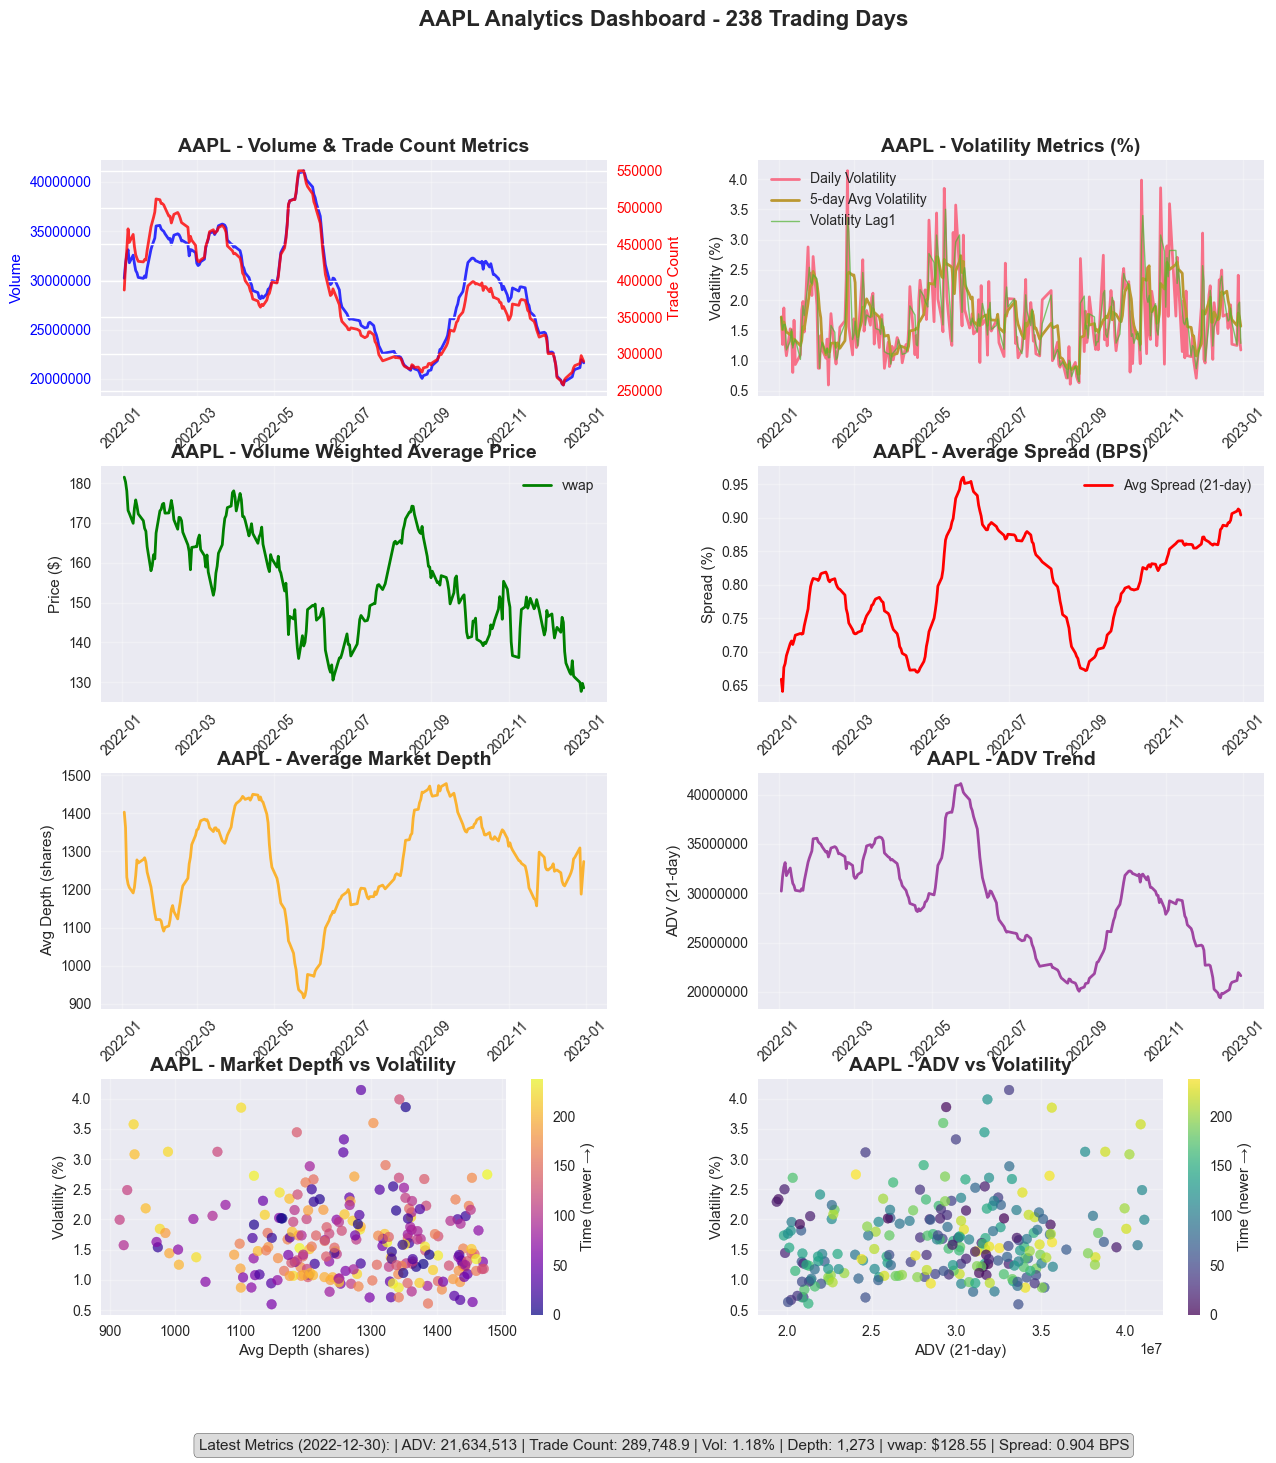

In [15]:
plot_examples()

In [44]:
# Dash Interactive Dashboard
import sys, time, threading, webbrowser

try:
    import dash
    from dash import dcc, html, Input, Output
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import pandas as pd
except ImportError:
    print(" Dash not installed. Install with: pip install dash plotly")
    print(" Using matplotlib plots instead")
    raise

def _in_jupyter() -> bool:
    try:
        from IPython import get_ipython  # noqa
        return "ipykernel" in sys.modules
    except Exception:
        return False

def create_analytics_dashboard():
    """Create a Dash web application for analytics visualization."""
    available_symbols = get_available_analytics_symbols()

    if len(available_symbols) == 0:
        print("❌ No analytics data available!")
        return None

    app = dash.Dash(__name__)

    app.layout = html.Div([
        html.H1("Stock Analytics Dashboard",
                style={'textAlign': 'center', 'marginBottom': 30}),

        html.Div([
            html.Label("Select Stock:", style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='symbol-dropdown',
                options=[{'label': s, 'value': s} for s in available_symbols],
                value=available_symbols[0],
                style={'width': '200px'}
            )
        ], style={'textAlign': 'center', 'marginBottom': 30}),

        dcc.Graph(id='analytics-plots', style={'height': '700px'}),

        html.Div(id='summary', style={'textAlign': 'center', 'marginTop': 20})
    ])

    @app.callback(
        [Output('analytics-plots', 'figure'), Output('summary', 'children')],
        [Input('symbol-dropdown', 'value')]
    )
    def update_dashboard(symbol):
        df = load_analytics_direct(symbol)

        if df is None or df.empty:
            return go.Figure(), f"No data for {symbol}"

        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date')

        # Create subplots
        fig = make_subplots(
            rows=3, cols=2,
            subplot_titles=[
                'Volume (ADV)', 'Trade Count',
                'Volatility (%)', 'vwap ($)',
                'Spread (BPS)', 'Market Depth'
            ]
        )

        # Volume plot
        if 'adv_21_days' in df.columns:
            fig.add_trace(go.Scatter(x=df['date'], y=df['adv_21_days'], name='ADV'), row=1, col=1)

        # Trade Count plot
        if 'avg_trade_count_21_days' in df.columns:
            fig.add_trace(go.Scatter(x=df['date'], y=df['avg_trade_count_21_days'], name='Trade Count'), row=1, col=2)

        # Volatility plot
        if 'daily_volatility' in df.columns:
            fig.add_trace(go.Scatter(x=df['date'], y=df['daily_volatility'] * 100, name='Daily Vol'), row=2, col=1)

        # vwap plot
        if 'vwap' in df.columns:
            fig.add_trace(go.Scatter(x=df['date'], y=df['vwap'], name='vwap'), row=2, col=2)

        # Spread plot
        if 'avg_spread_21_days' in df.columns:
            fig.add_trace(go.Scatter(x=df['date'], y=df['avg_spread_21_days'] * 10000, name='Spread (BPS)'), row=3, col=1)

        # Market Depth plot
        if 'avg_depth_21_days' in df.columns:
            fig.add_trace(go.Scatter(x=df['date'], y=df['avg_depth_21_days'], name='Avg Depth'), row=3, col=2)

        fig.update_layout(height=900, title=f"{symbol} Analytics", showlegend=False)

        # Summary
        latest = df.iloc[-1]
        summary_parts = []
        if 'adv_21_days' in df.columns:
            summary_parts.append(f"ADV: {latest['adv_21_days']:,.0f}")
        if 'avg_trade_count_21_days' in df.columns:
            summary_parts.append(f"Trade Count: {latest['avg_trade_count_21_days']:,.1f}")
        if 'daily_volatility' in df.columns:
            summary_parts.append(f"Volatility: {latest['daily_volatility']*100:.2f}%")
        if 'avg_depth_21_days' in df.columns:
            summary_parts.append(f"Depth: {latest['avg_depth_21_days']:,.0f}")
        if 'vwap' in df.columns:
            summary_parts.append(f"vwap: ${latest['vwap']:.2f}")

        summary = html.Div([html.P(" | ".join(summary_parts))])
        return fig, summary

    return app

def run_dashboard(port=8051, host='127.0.0.1', open_browser=True):
    """Run the dashboard."""
    app = create_analytics_dashboard()
    if not app:
        print("❌ No app created!")
        return

    print(f" Dashboard starting at http://{host}:{port}")

    # Only auto-open a browser if we're NOT in Jupyter
    if open_browser and not _in_jupyter():
        def _open():
            time.sleep(1.5)
            try:
                webbrowser.open(f'http://{host}:{port}')
            except Exception as e:
                print(f"❌ Error opening browser: {e}")
        threading.Thread(target=_open, daemon=True).start()

    # Dash >=2.7 uses app.run; pass host explicitly to avoid bad defaults
    try:
        app.run(host=host, port=port, debug=False, use_reloader=False)
    except TypeError:
        # Very old Dash fallback
        app.run_server(host=host, port=port, debug=False)

print(" Dash dashboard ready! Run 'run_dashboard()' to start")


 Dash dashboard ready! Run 'run_dashboard()' to start


In [45]:
run_dashboard()


Checking analytics directory: mana_data/daily_analytics_parquet
Found 402 items in analytics directory
  Found symbol: SWKS
  Found symbol: TSN
  Found symbol: DAL
  Found symbol: ITW
  Found symbol: ES
Total symbols with analytics: 402
 Dashboard starting at http://127.0.0.1:8051


In [41]:
%tb

SystemExit: 1

In [ ]:
# Investigate volatility issues - let's examine some stocks with missing volatility
import numpy as np

def investigate_volatility_issues():
    """Investigate why some stocks have no volatility data."""
    
    available_symbols = get_available_analytics_symbols()
    print(f"Checking volatility issues across {len(available_symbols)} symbols...")
    
    # Check for stocks with NaN volatility
    stocks_with_nan_vol = []
    stocks_with_zero_vol = []
    stocks_with_valid_vol = []
    
    for symbol in available_symbols:  # Check first 50 for speed
        try:
            df = load_analytics_direct(symbol)
            if df.empty:
                continue
                
            vol_data = df['daily_volatility']
            
            if vol_data.isna().all():
                stocks_with_nan_vol.append(symbol)
            elif (vol_data == 0).all():
                stocks_with_zero_vol.append(symbol)
            elif vol_data.isna().any():
                # Some but not all are NaN
                nan_count = vol_data.isna().sum()
                total_count = len(vol_data)
                print(f"  {symbol}: {nan_count}/{total_count} days have NaN volatility")
                stocks_with_valid_vol.append(symbol)
            else:
                stocks_with_valid_vol.append(symbol)
                
        except Exception as e:
            print(f"Error checking {symbol}: {e}")
    
    print(f"\n📊 Volatility Investigation Results:")
    print(f"  ✅ Stocks with valid volatility: {len(stocks_with_valid_vol)}")
    print(f"  ❌ Stocks with ALL NaN volatility: {len(stocks_with_nan_vol)}")
    print(f"  ⚠️  Stocks with ALL zero volatility: {len(stocks_with_zero_vol)}")
    
    if stocks_with_nan_vol:
        print(f"\n🔍 Stocks with NaN volatility: {stocks_with_nan_vol[:10]}")
        
        # Let's examine the raw data for one of these stocks
        problem_symbol = stocks_with_nan_vol[0]
        print(f"\n🔍 Investigating {problem_symbol} raw data...")
        
        # Load raw data to see what's happening
        df_raw = load_symbol_ultra_fast(problem_symbol)
        if not df_raw.empty:
            print(f"  Raw data shape: {df_raw.shape}")
            print(f"  Date range: {df_raw['date'].min()} to {df_raw['date'].max()}")
            
            # Check price data
            price_cols = ['trade_last', 'trade_high', 'trade_low']
            for col in price_cols:
                if col in df_raw.columns:
                    valid_count = (df_raw[col] > 0).sum()
                    total_count = len(df_raw)
                    print(f"  {col}: {valid_count}/{total_count} valid prices")
                    if valid_count > 0:
                        print(f"    Sample values: {df_raw[col][df_raw[col] > 0].head().tolist()}")
            
            # Check for specific issue: all prices equal (no intraday movement)
            if 'trade_high' in df_raw.columns and 'trade_low' in df_raw.columns:
                same_high_low = (df_raw['trade_high'] == df_raw['trade_low']).sum()
                total_valid = ((df_raw['trade_high'] > 0) & (df_raw['trade_low'] > 0)).sum()
                if total_valid > 0:
                    print(f"  Days with High = Low: {same_high_low}/{total_valid} ({same_high_low/total_valid*100:.1f}%)")
    
    if stocks_with_zero_vol:
        print(f"\n🔍 Stocks with zero volatility: {stocks_with_zero_vol[:5]}")
    
    return stocks_with_nan_vol, stocks_with_zero_vol, stocks_with_valid_vol

# Run the investigation
nan_vol_stocks, zero_vol_stocks, valid_vol_stocks = investigate_volatility_issues()


Checking analytics directory: mana_data/daily_analytics_parquet
Found 402 items in analytics directory
  Found symbol: SWKS
  Found symbol: TSN
  Found symbol: DAL
  Found symbol: ITW
  Found symbol: ES
Total symbols with analytics: 402
Checking volatility issues across 402 symbols...

📊 Volatility Investigation Results:
  ✅ Stocks with valid volatility: 402
  ❌ Stocks with ALL NaN volatility: 0
  ⚠️  Stocks with ALL zero volatility: 0


In [27]:
# Test the enhanced volatility calculation
def test_enhanced_volatility(test_symbols=None):
    """Test the enhanced volatility calculation on specific symbols."""
    
    if test_symbols is None:
        # Use some symbols that likely have issues, plus a known good one
        available_symbols = get_available_analytics_symbols()
        test_symbols = available_symbols[:5]  # Test first 5
    
    print(f"🧪 Testing enhanced volatility calculation on {len(test_symbols)} symbols...")
    
    for symbol in test_symbols:
        print(f"\n--- Testing {symbol} ---")
        try:
            # Load raw data
            df_raw = load_symbol_ultra_fast(symbol)
            if df_raw.empty:
                print(f"  ❌ No raw data for {symbol}")
                continue
            
            print(f"  📊 Raw data: {len(df_raw)} records")
            print(f"  📊 Raw columns: {df_raw.columns}")
            
            # Test the enhanced analytics calculation
            analytics_enhanced = calculate_analytics_robust(df_raw, symbol)
            
            if analytics_enhanced.empty:
                print(f"  ❌ Enhanced calculation failed")
                continue
            
            # Compare with existing analytics
            existing_analytics = load_analytics_direct(symbol)
            
            print(f"  📈 Enhanced analytics: {len(analytics_enhanced)} days")
            print(f"   Enhanced analytics columns: {analytics_enhanced.head(3)}")
            
            # Check volatility results
            vol_data = analytics_enhanced['daily_volatility']
            nan_count = vol_data.isna().sum()
            zero_count = (vol_data == 0).sum()
            valid_count = len(vol_data) - nan_count - zero_count
            
            print(f"  📊 Volatility results:")
            print(f"    • Valid: {valid_count}/{len(vol_data)} days")
            print(f"    • NaN: {nan_count} days")
            print(f"    • Zero: {zero_count} days")
            print(f"    • Range: {vol_data.min():.6f} to {vol_data.max():.6f}")
            print(f"    • Mean: {vol_data.mean():.6f}")
        
            
            # Show sample data
            if valid_count > 0:
                sample_data = analytics_enhanced[['date', 'daily_volatility', 'trade_high', 'trade_low']].head(3)
                print(f"  📋 Sample data:")
                for _, row in sample_data.iterrows():
                    print(f"    {row['date']}: vol={row['daily_volatility']:.6f}, H={row['trade_high']:.2f}, L={row['trade_low']:.2f}")
            
        except Exception as e:
            print(f"  ❌ Error testing {symbol}: {e}")
    
    print(f"\n✅ Enhanced volatility testing complete!")

# Run the test
test_enhanced_volatility()


Checking analytics directory: mana_data/daily_analytics_parquet
Found 402 items in analytics directory
  Found symbol: SWKS
  Found symbol: TSN
  Found symbol: DAL
  Found symbol: ITW
  Found symbol: ES
Total symbols with analytics: 402
🧪 Testing enhanced volatility calculation on 5 symbols...

--- Testing A ---
  📊 Raw data: 93058 records
  📊 Raw columns: Index(['time', 'trade_count', 'trade_volume', 'trade_last', 'trade_high',
       'trade_low', 'bid_price', 'bid_size', 'ask_price', 'ask_size',
       'hid_vol', 'buy_vol', 'sell_vol', 'unsided_vol', 'vwap', 'symbol',
       'date'],
      dtype='object')
  📈 Enhanced analytics: 238 days
   Enhanced analytics columns:   symbol       date    adv_21_days  avg_trade_count_21_days  \
0      A 2022-01-03  569254.000000                  18112.0   
1      A 2022-01-04  707956.000000                  21049.5   
2      A 2022-01-05  732339.666667                  20991.0   

   avg_spread_21_days  avg_depth_21_days        vwap  daily_volatili

In [20]:
# Function to regenerate analytics for specific symbols with volatility issues
def fix_volatility_for_symbols(symbols_to_fix=None):
    """
    Regenerate analytics with enhanced volatility calculation for specific symbols.
    
    @param symbols_to_fix: List of symbols to fix. If None, will identify and fix all symbols with volatility issues.
    """
    
    if symbols_to_fix is None:
        print("🔍 Identifying symbols with volatility issues...")
        available_symbols = get_available_analytics_symbols()
        symbols_to_fix = []
        
        # Check each symbol for volatility issues
        for symbol in available_symbols:
            try:
                df = load_analytics_direct(symbol)
                if df.empty:
                    continue
                    
                vol_data = df['daily_volatility']
                if vol_data.isna().all() or (vol_data.isna().sum() / len(vol_data)) > 0.5:
                    symbols_to_fix.append(symbol)
                    
            except Exception as e:
                print(f"Error checking {symbol}: {e}")
        
        print(f"Found {len(symbols_to_fix)} symbols with volatility issues")
    
    if not symbols_to_fix:
        print("✅ No symbols need volatility fixes!")
        return
    
    print(f"🔧 Fixing volatility for {len(symbols_to_fix)} symbols...")
    
    fixed_count = 0
    
    for symbol in tqdm(symbols_to_fix, desc="Fixing volatility"):
        try:
            # Load raw data
            df_raw = load_symbol_ultra_fast(symbol)
            if df_raw.empty:
                print(f"X No raw data for {symbol}")
                continue
            
            # Calculate analytics with enhanced volatility
            analytics = calculate_analytics_robust(df_raw, symbol)
            
            if analytics.empty:
                print(f"X Failed to calculate analytics for {symbol}")
                continue
            
            # Save the updated analytics by date
            for date_val, date_data in analytics.groupby('date'):
                # Format date as YYYYMMDD
                if hasattr(date_val, 'strftime'):
                    date_str = date_val.strftime('%Y%m%d')
                else:
                    date_str = pd.to_datetime(date_val).strftime('%Y%m%d')
                
                # Create directory structure: sym={symbol}/date=YYYYMMDD/
                date_dir = Path(OUTPUT_PATH) / f"sym={symbol}" / f"date={date_str}"
                date_dir.mkdir(parents=True, exist_ok=True)
                
                # Save the analytics for this specific date
                date_data.to_parquet(date_dir / "analytics.parquet", index=False)
            fixed_count += 1
            
        except Exception as e:
            print(f"X Error fixing {symbol}: {e}")
    
    print(f"✅ Fixed volatility for {fixed_count}/{len(symbols_to_fix)} symbols")
    
    return fixed_count

def quick_volatility_check():
    """Quick check of volatility across all symbols."""
    
    available_symbols = get_available_analytics_symbols()
    print(f"📊 Checking volatility for {len(available_symbols)} symbols...")
    
    total_symbols = 0
    symbols_with_issues = 0
    
    for symbol in available_symbols:
        try:
            df = load_analytics_direct(symbol)
            if df.empty:
                continue
                
            total_symbols += 1
            vol_data = df['daily_volatility']
            
            # Check for issues
            nan_ratio = vol_data.isna().sum() / len(vol_data)
            if nan_ratio > 0.1:  # More than 10% NaN
                symbols_with_issues += 1
                
        except Exception:
            continue
    
    print(f"📈 Results:")
    print(f"  • Total symbols checked: {total_symbols}")
    print(f"  • Symbols with volatility issues: {symbols_with_issues}")
    print(f"  • Healthy symbols: {total_symbols - symbols_with_issues}")
    
    if symbols_with_issues > 0:
        print(f"\n💡 Run 'fix_volatility_for_symbols()' to fix these issues")
    
    return symbols_with_issues

print("✓ Volatility fix functions ready!")


✓ Volatility fix functions ready!
